## Using Python to Analyze Maryland Car Crash Data

While this post is about Car Crashes in Maryland, the purpose for me was to to test a package I had just found called jupyter_to_medium.  In this process I tested the package and the process of using mediums API to more quickly move from a Jupyter Notebook, where I wrote this, to Medium. https://pypi.org/project/jupyter-to-medium/   You can find a great tutorial and video here.  https://medium.com/dunder-data/jupyter-to-medium-initial-post-ecd140d339f0

The data for this analysis is pubically available from Maryland located here:
https://opendata.maryland.gov/Public-Safety/Maryland-Statewide-Vehicle-Crashes/65du-s3qu


## Initial Setup and Import

In [11]:
import pandas as pd
import plotly.express as px
import plotly.io as pio
import time
from IPython.display import Image, display
import jupyter_to_medium
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('C:\\Users\\Ben\\OneDrive\\Documents\\Medium Posts\\Maryland_Car_Crashes\\Maryland_Statewide_Vehicle_Crashes.csv')
df = df[['YEAR', 'LIGHT_DESC', 'COUNTY_DESC', 'REPORT_TYPE', 'WEATHER_DESC', 'ACC_DATE', 'ACC_TIME', 'LATITUDE', 'LONGITUDE', 'JUNCTION_DESC']]

In [12]:
# Top ten counties
top_five_counties = df['COUNTY_DESC'].value_counts().head(5).index.tolist()

# Filter a dataframe to only top ten counties
df_top_five = df[df['COUNTY_DESC'].isin(top_five_counties)]

In [15]:
pivot_table = df_top_five.pivot_table(index='REPORT_TYPE', columns='COUNTY_DESC', 
                                     values='YEAR', aggfunc='count')

# Convert the counts to percentages
pivot_percentage = pivot_table.div(pivot_table.sum(axis=0), axis=1)*100

# Display the resulting pivot table with percentages
pivot_table.T
pivot_percentage.T

REPORT_TYPE,Fatal Crash,Injury Crash,Property Damage Crash
COUNTY_DESC,,,
Anne Arundel,0.431825,30.174319,69.393856
Baltimore,0.214214,22.926467,76.859319
Baltimore City,0.089282,29.238131,70.672587
Montgomery,0.269530,33.090118,66.640353
Prince George's,0.480614,24.359822,75.159564


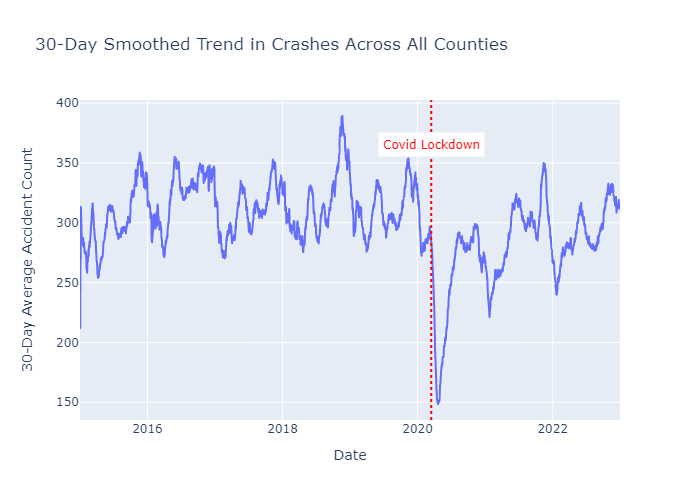

In [16]:
# Convert ACC_DATE to datetime format
df['ACC_DATE'] = pd.to_datetime(df['ACC_DATE'], format='%Y%m%d')

# Combine ACC_DATE and ACC_TIME into a single datetime column
df['ACC_DATETIME'] = pd.to_datetime(df['ACC_DATE'].astype(str) + ' ' + df['ACC_TIME'].astype(str).str[-8:])

# Extract hour and month from ACC_DATETIME
df['HOUR'] = df['ACC_DATETIME'].dt.hour
df['MONTH'] = df['ACC_DATETIME'].dt.month

# Create a new DataFrame with daily accident counts for each county
daily_counts = df.groupby(['ACC_DATE']).size().reset_index()
daily_counts.columns = ['ACC_DATE', 'COUNT']

# Apply a 30-day rolling average to the COUNT column for each county
daily_counts['SMOOTHED_COUNT'] = daily_counts['COUNT'].rolling(30, min_periods=1).mean()

# Create the line plot using the smoothed data
fig = px.line(daily_counts, x='ACC_DATE', y='SMOOTHED_COUNT', title='Car Crash Trend In Maryland (30 Day Smoothed)')

fig = px.line(daily_counts, 
              x='ACC_DATE', 
              y='SMOOTHED_COUNT', 
              title='30-Day Smoothed Trend in Crashes Across All Counties', 
              labels={'ACC_DATE': 'Date', 'SMOOTHED_COUNT': '30-Day Average Accident Count'})

# Add your annotations and vertical line as before
fig.add_shape(
    type="line",
    x0="2020-03-15",
    x1="2020-03-15",
    y0=0,
    y1=1,
    yref="paper",
    line=dict(
        color="red",
        width=2,
        dash="dot",
    )
)
fig.add_annotation(
    x="2020-03-15",
    y=.9,
    yref="paper",
    text="Covid Lockdown",
    showarrow=False,
    font=dict(
        color="red"
    ),
    bgcolor="white",
    borderpad=4
)

pio.write_image(fig, '30DayTrend_AllCounties.png')
display(Image(filename='30DayTrend_AllCounties.png'))



## TimeSeries Trend by County

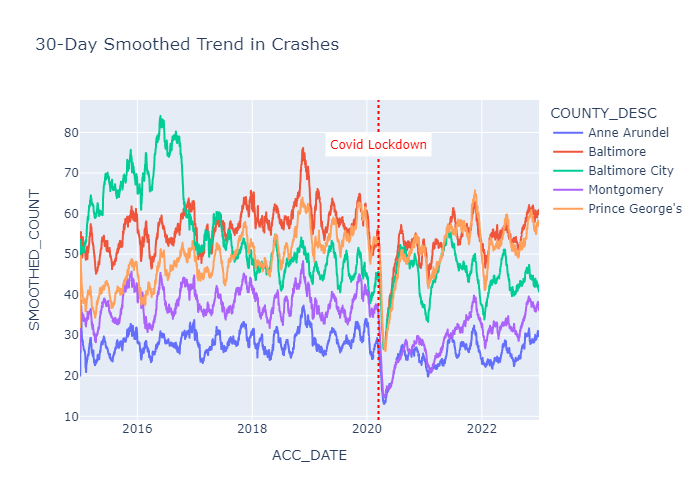

In [17]:
# Convert ACC_DATE to datetime format
df['ACC_DATE'] = pd.to_datetime(df['ACC_DATE'], format='%Y%m%d')

# Combine ACC_DATE and ACC_TIME into a single datetime column
df['ACC_DATETIME'] = pd.to_datetime(df['ACC_DATE'].astype(str) + ' ' + df['ACC_TIME'].astype(str).str[-8:])

# Extract hour and month from ACC_DATETIME
df['HOUR'] = df['ACC_DATETIME'].dt.hour
df['MONTH'] = df['ACC_DATETIME'].dt.month

# Create a new DataFrame with daily accident counts for each county
daily_counts = df.groupby(['ACC_DATE', 'COUNTY_DESC']).size().reset_index()
daily_counts.columns = ['ACC_DATE', 'COUNTY_DESC', 'COUNT']

# Apply a 30-day rolling average to the COUNT column for each county
daily_counts['SMOOTHED_COUNT'] = daily_counts.groupby('COUNTY_DESC')['COUNT'].transform(lambda x: x.rolling(30, min_periods=1).mean())

# Create the line plot using the smoothed data
fig = px.line(daily_counts[daily_counts['COUNTY_DESC'].isin(top_five_counties)], x='ACC_DATE', y='SMOOTHED_COUNT', color='COUNTY_DESC', title='30-Day Smoothed Trend in Crashes')

# Adding a vertical red dotted line
fig.add_shape(
    type="line",
    x0="2020-03-15",
    x1="2020-03-15",
    y0=0,
    y1=1,
    yref="paper",  # This means the y coordinates are given in relative coordinates (0 to 1 covers the whole plot)
    line=dict(
        color="red",
        width=2,
        dash="dot",
    )
)
fig.add_annotation(
    x="2020-03-15",
    y=.9,
    yref="paper",
    text="Covid Lockdown",
    showarrow=False,
    font=dict(
        color="red"
    ),
    bgcolor="white",
    borderpad=4
)

pio.write_image(fig, '30DayTrend.png')
display(Image(filename='30DayTrend.png'))


In [18]:
# Filter the data to include only rows from the top_five_counties
filtered_counts = daily_counts[daily_counts['COUNTY_DESC'].isin(top_five_counties)]

# Split the data into two subsets: before and after March 1, 2020
before_covid = filtered_counts[filtered_counts['ACC_DATE'] < '2020-03-01']
after_covid = filtered_counts[filtered_counts['ACC_DATE'] >= '2020-03-01']

# Calculate the average crashes per day for each county for the two time periods
avg_before_covid = before_covid.groupby('COUNTY_DESC')['COUNT'].mean().reset_index()
avg_after_covid = after_covid.groupby('COUNTY_DESC')['COUNT'].mean().reset_index()

# Merge the results to create a combined DataFrame
merged = avg_before_covid.merge(avg_after_covid, on='COUNTY_DESC', suffixes=('_PRE', '_POST'))

# Calculate the percent difference
merged['PERCENT_DIFF'] = ((merged['COUNT_POST'] - merged['COUNT_PRE']) / merged['COUNT_PRE']) * 100

# Rename the columns for clarity
merged.columns = ['COUNTY_DESC', 'Avg Crashes/Day (Pre-Covid)', 'Avg Crashes/Day (Post-Covid)', 'Percent Difference']
merged.sort_values(by="Percent Difference", ascending=False, inplace=True)

merged.style.bar(subset=['Percent Difference'], color='#d65f5f')


,COUNTY_DESC,Avg Crashes/Day (Pre-Covid),Avg Crashes/Day (Post-Covid),Percent Difference
4,Prince George's,48.954401,51.023166,4.225902
1,Baltimore,56.975080,52.858108,-7.225916
0,Anne Arundel,28.312831,24.919884,-11.983779
2,Baltimore City,56.037646,44.093629,-21.314272
3,Montgomery,37.935313,29.471042,-22.312378


## Fatal Crashes

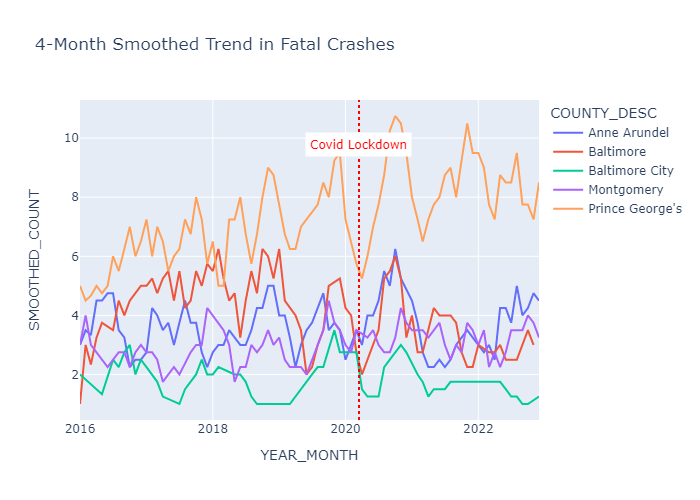

In [19]:
# Filter the data for fatal crashes
df_Fatal = df[df['REPORT_TYPE'] == 'Fatal Crash']

# Extract year from ACC_DATETIME for monthly aggregation
df_Fatal['YEAR'] = df_Fatal['ACC_DATETIME'].dt.year

# Create a new DataFrame with monthly fatal accident counts for each county
monthly_fatal_counts = df_Fatal.groupby(['YEAR', 'MONTH', 'COUNTY_DESC']).size().reset_index()
monthly_fatal_counts.columns = ['YEAR', 'MONTH', 'COUNTY_DESC', 'COUNT']

# Apply a 4-month rolling average to the COUNT column for each county
monthly_fatal_counts['SMOOTHED_COUNT'] = monthly_fatal_counts.groupby('COUNTY_DESC')['COUNT'].transform(lambda x: x.rolling(4, min_periods=1).mean())

# Create a new column for plotting purposes: "YEAR-MONTH"
monthly_fatal_counts['YEAR_MONTH'] = monthly_fatal_counts['YEAR'].astype(str) + '-' + monthly_fatal_counts['MONTH'].astype(str).str.zfill(2)

# Create the line plot using the smoothed data
fig = px.line(monthly_fatal_counts[monthly_fatal_counts['COUNTY_DESC'].isin(top_five_counties)], x='YEAR_MONTH', y='SMOOTHED_COUNT', color='COUNTY_DESC', title='4-Month Smoothed Trend in Fatal Crashes')

# Adding a vertical red dotted line
fig.add_shape(
    type="line",
    x0="2020-03-15",
    x1="2020-03-15",
    y0=0,
    y1=1,
    yref="paper",  # This means the y coordinates are given in relative coordinates (0 to 1 covers the whole plot)
    line=dict(
        color="red",
        width=2,
        dash="dot",
    )
)
fig.add_annotation(
    x="2020-03-15",
    y=.9,
    yref="paper",
    text="Covid Lockdown",
    showarrow=False,
    font=dict(
        color="red"
    ),
    bgcolor="white",
    borderpad=4
)

# Show the plot
pio.write_image(fig, '4MonthTrend.png')
display(Image(filename='4MonthTrend.png'))


In [20]:
# Filter the data to include only rows from the top_five_counties
filtered_fatal_counts = monthly_fatal_counts[monthly_fatal_counts['COUNTY_DESC'].isin(top_five_counties)]

# Create a 'MONTH_YEAR' column for easier filtering
filtered_fatal_counts['MONTH_YEAR'] = pd.to_datetime(filtered_fatal_counts['YEAR'].astype(str) + '-' + filtered_fatal_counts['MONTH'].astype(str) + '-01')

# Split the data into two subsets: before and after March 1, 2020
before_covid_fatal = filtered_fatal_counts[filtered_fatal_counts['MONTH_YEAR'] < '2020-03-01']
after_covid_fatal = filtered_fatal_counts[filtered_fatal_counts['MONTH_YEAR'] >= '2020-03-01']

# Calculate the average fatal crashes per month for each county for the two time periods
avg_before_covid_fatal = before_covid_fatal.groupby('COUNTY_DESC')['COUNT'].mean().reset_index()
avg_after_covid_fatal = after_covid_fatal.groupby('COUNTY_DESC')['COUNT'].mean().reset_index()

# Merge the results to create a combined DataFrame
merged_fatal = avg_before_covid_fatal.merge(avg_after_covid_fatal, on='COUNTY_DESC', suffixes=('_PRE', '_POST'))

# Calculate the percent difference
merged_fatal['PERCENT_DIFF'] = ((merged_fatal['COUNT_POST'] - merged_fatal['COUNT_PRE']) / merged_fatal['COUNT_PRE']) * 100

# Rename the columns for clarity
merged_fatal.columns = ['COUNTY_DESC', 'Avg Fatal Crashes/Month (Pre-Covid)', 'Avg Fatal Crashes/Month (Post-Covid)', 'Percent Difference']
merged_fatal.sort_values(by="Percent Difference", ascending=False, inplace=True)


merged_fatal.style.bar(subset=['Percent Difference'], color='#d65f5f')


,COUNTY_DESC,Avg Fatal Crashes/Month (Pre-Covid),Avg Fatal Crashes/Month (Post-Covid),Percent Difference
4,Prince George's,6.700000,8.529412,27.304653
3,Montgomery,2.812500,3.250000,15.555556
0,Anne Arundel,3.520000,3.843750,9.197443
2,Baltimore City,1.972222,1.653846,-16.143012
1,Baltimore,4.489362,3.392857,-24.424509


## Explore All Counties

In [21]:
# Instead of filtering, you directly use the entire daily_counts data
before_covid = daily_counts[daily_counts['ACC_DATE'] < '2020-03-01']
after_covid = daily_counts[daily_counts['ACC_DATE'] >= '2020-03-01']

# Calculate the average crashes per day for each county for the two time periods
avg_before_covid = before_covid.groupby('COUNTY_DESC')['COUNT'].mean().reset_index()
avg_after_covid = after_covid.groupby('COUNTY_DESC')['COUNT'].mean().reset_index()

# Merge the results to create a combined DataFrame
merged = avg_before_covid.merge(avg_after_covid, on='COUNTY_DESC', suffixes=('_PRE', '_POST'))

# Calculate the percent difference
merged['PERCENT_DIFF'] = ((merged['COUNT_POST'] - merged['COUNT_PRE']) / merged['COUNT_PRE']) * 100

# Rename the columns for clarity
merged.columns = ['COUNTY_DESC', 'Avg Crashes/Day (Pre-Covid)', 'Avg Crashes/Day (Post-Covid)', 'Percent Difference']
merged.sort_values(by="Percent Difference", ascending=False, inplace=True)

merged.style.bar(subset=['Percent Difference'], color='#d65f5f')


,COUNTY_DESC,Avg Crashes/Day (Pre-Covid),Avg Crashes/Day (Post-Covid),Percent Difference
0,Allegany,2.164199,2.338355,8.047105
16,Prince George's,48.954401,51.023166,4.225902
5,Caroline,1.817700,1.853297,1.958353
23,Worcester,3.990857,4.057173,1.661683
14,Kent,1.385661,1.386412,0.054168
9,Dorchester,1.911064,1.883117,-1.462407
17,Queen Anne's,2.490831,2.444321,-1.867272
19,St. Mary's,4.591595,4.447106,-3.146816
21,Washington,6.884328,6.644250,-3.487324
20,Talbot,2.503681,2.393534,-4.399402


In [22]:
# Filter the data for fatal crashes
df_Fatal = df[df['REPORT_TYPE'] == 'Fatal Crash']

# Extract year and month from ACC_DATETIME for aggregation
df_Fatal['YEAR'] = df_Fatal['ACC_DATETIME'].dt.year
df_Fatal['MONTH'] = df_Fatal['ACC_DATETIME'].dt.month

# Create a new DataFrame with monthly fatal accident counts for each county
monthly_fatal_counts = df_Fatal.groupby(['YEAR', 'MONTH', 'COUNTY_DESC']).size().reset_index()
monthly_fatal_counts.columns = ['YEAR', 'MONTH', 'COUNTY_DESC', 'COUNT']

# Create a 'MONTH_YEAR' column for easier filtering
monthly_fatal_counts['MONTH_YEAR'] = pd.to_datetime(monthly_fatal_counts['YEAR'].astype(str) + '-' + monthly_fatal_counts['MONTH'].astype(str) + '-01')

# Split the data into two subsets: before and after March 1, 2020
before_covid_fatal = monthly_fatal_counts[monthly_fatal_counts['MONTH_YEAR'] < '2020-03-01']
after_covid_fatal = monthly_fatal_counts[monthly_fatal_counts['MONTH_YEAR'] >= '2020-03-01']

# Calculate the average fatal crashes per month for each county for the two time periods
avg_before_covid_fatal = before_covid_fatal.groupby('COUNTY_DESC')['COUNT'].mean().reset_index()
avg_after_covid_fatal = after_covid_fatal.groupby('COUNTY_DESC')['COUNT'].mean().reset_index()

# Merge the results to create a combined DataFrame
merged_fatal = avg_before_covid_fatal.merge(avg_after_covid_fatal, on='COUNTY_DESC', suffixes=('_PRE', '_POST'))

# Calculate the percent difference
merged_fatal['PERCENT_DIFF'] = ((merged_fatal['COUNT_POST'] - merged_fatal['COUNT_PRE']) / merged_fatal['COUNT_PRE']) * 100

# Rename the columns for clarity
merged_fatal.columns = ['COUNTY_DESC', 'Avg Fatal Crashes/Month (Pre-Covid)', 'Avg Fatal Crashes/Month (Post-Covid)', 'Pct Difference Fatal']
merged_fatal.sort_values(by="Pct Difference Fatal", ascending=False, inplace=True)

merged_fatal.style.bar(subset=['Pct Difference Fatal'], color='#d65f5f')


,COUNTY_DESC,Avg Fatal Crashes/Month (Pre-Covid),Avg Fatal Crashes/Month (Post-Covid),Pct Difference Fatal
23,Worcester,1.272727,1.850000,45.357143
13,Howard,2.078947,2.862069,37.669140
16,Prince George's,6.700000,8.529412,27.304653
14,Kent,1.000000,1.230769,23.076923
10,Frederick,1.883721,2.225806,18.160096
15,Montgomery,2.812500,3.250000,15.555556
1,Anne Arundel,3.520000,3.843750,9.197443
12,Harford,1.775000,1.925926,8.502869
19,St. Mary's,1.628571,1.695652,4.118993
21,Washington,1.700000,1.720000,1.176471


In [23]:
final_df = merged.merge(merged_fatal, on='COUNTY_DESC', how='left')
final_df.head()

,COUNTY_DESC,Avg Crashes/Day (Pre-Covid),Avg Crashes/Day (Post-Covid),Percent Difference,Avg Fatal Crashes/Month (Pre-Covid),Avg Fatal Crashes/Month (Post-Covid),Pct Difference Fatal
0,Allegany,2.164199,2.338355,8.047105,1.437500,1.176471,-18.158568
1,Prince George's,48.954401,51.023166,4.225902,6.700000,8.529412,27.304653
2,Caroline,1.817700,1.853297,1.958353,1.217391,1.083333,-11.011905
3,Worcester,3.990857,4.057173,1.661683,1.272727,1.850000,45.357143
4,Kent,1.385661,1.386412,0.054168,1.000000,1.230769,23.076923


In [62]:
import plotly.express as px

# Set the max value for size normalization
max_size = final_df["Percent Difference"].max()

# Normalize size values to ensure all are positive and represent the actual value direction
normalized_size = (final_df["Percent Difference"] - final_df["Percent Difference"].min()) / (max_size - final_df["Percent Difference"].min())

# Create the scatter plot
fig = px.scatter(final_df, 
                 x="Pct Difference Fatal",  
                 y="Percent Difference",  
                 hover_name="COUNTY_DESC", 
                 color="Pct Difference Fatal",  
                 color_continuous_scale='Reds',
                 size=normalized_size,  # Using normalized values for sizes
                 title="Maryand Crashes: Percent Change After Covid - Overall and Fatal"
                 )

# Customize axes labels and ranges
max_diff = max(final_df["Percent Difference"].abs().max(), final_df["Pct Difference Fatal"].abs().max())
fig.update_layout(
    yaxis_title="Percent Difference (Overall Crashes)",
    xaxis_title="Percent Difference (Fatal Crashes)",
    yaxis=dict(range=[-max_diff+10, max_diff-10]),  
    xaxis=dict(range=[-max_diff-5, max_diff+5])  
)

# Update marker properties to have a black border
fig.update_traces(marker=dict(line=dict(width=1, color='Black')))

# Update hover template to show county name and X, Y values with only three significant digits
fig.update_traces(hovertemplate='%{hovertext}<br>X: %{x:.3}<br>Y: %{y:.3}')

# Display the figure
fig.show()


In [67]:
import chart_studio
import chart_studio.plotly as py
import chart_studio.tools as tls

username='ben.g.ballard'
api_key='HDFPYBDpTUYCes6CToal'
chart_studio.tools.set_credentials_file(username=username,
                                        api_key=api_key)

In [68]:
py.plot(fig, filename="Maryland_Crashes", auto_open = True)


'https://plotly.com/~ben.g.ballard/24/'